EDA Analysis

Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Load Datasets

In [15]:
train_data = pd.read_csv("../dataset/train_metadata.csv")
val_data = pd.read_csv("../dataset/val_metadata.csv")
test_data = pd.read_csv("../dataset/test_metadata.csv")

Class Distribution

In [16]:
train_data["dx"].value_counts

<bound method IndexOpsMixin.value_counts of 0        nv
1        nv
2        nv
3        nv
4        nv
       ... 
7004     nv
7005    bkl
7006     nv
7007     nv
7008     nv
Name: dx, Length: 7009, dtype: str>

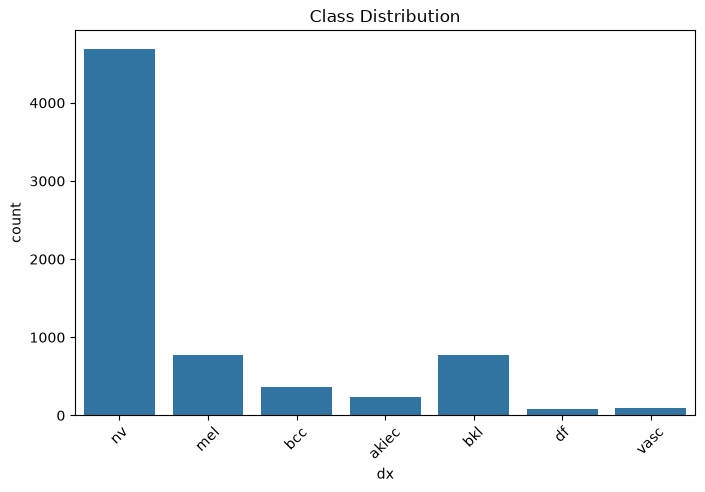

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_data,
    x="dx"
)

plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

3. Pixel Intensity Analysis

In [18]:
import cv2
import numpy as np

img = cv2.imread(
    train_data.iloc[0]["image_path"]
)

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_array = np.array(img)

In [20]:

print(img_array.min())
print(img_array.max())

18
193


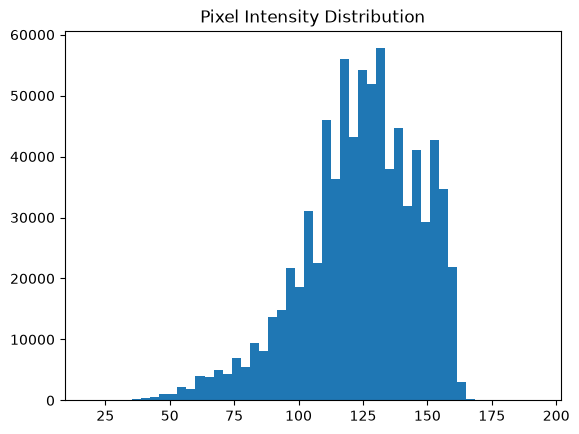

In [21]:
plt.hist(
    img_array.ravel(),
    bins=50
)

plt.title("Pixel Intensity Distribution")
plt.show()

4. Image Augmentation Comparison

In [22]:
image = cv2.imread(
    train_data.iloc[0]["image_path"]
)

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image
image = cv2.resize(image, (224, 224))

In [23]:
import tensorflow as tf

In [24]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomFlip(
        "horizontal_and_vertical"
    ),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2)

])

In [25]:
aug_img = data_augmentation(
    np.expand_dims(
        np.array(image)/255.0,
        axis=0
    )
)

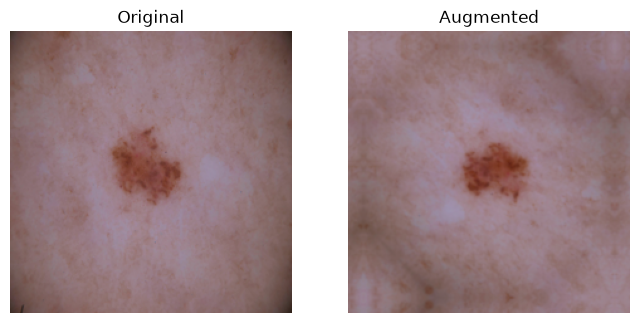

In [12]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(aug_img[0])
plt.title("Augmented")
plt.axis("off")

plt.show()

5. Class-wise Image Characteristics

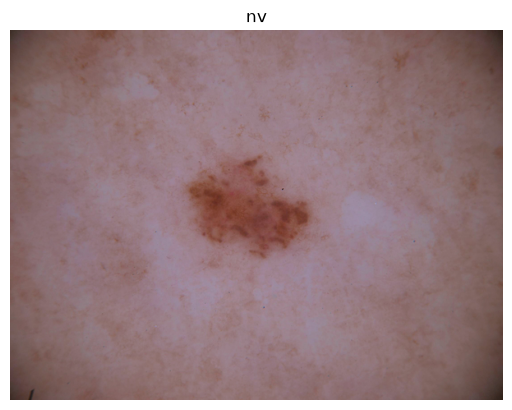

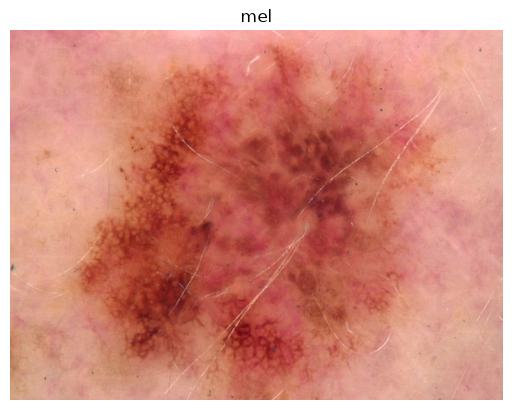

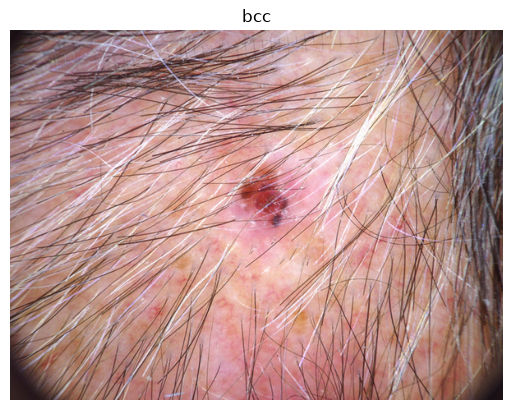

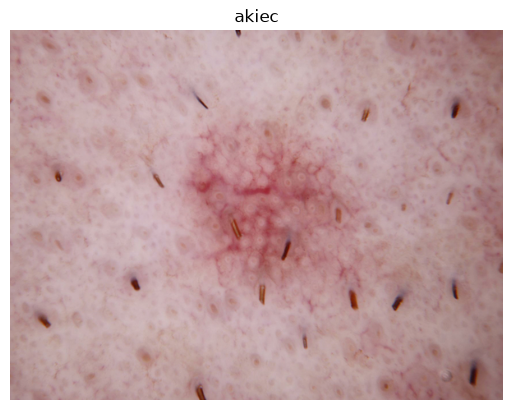

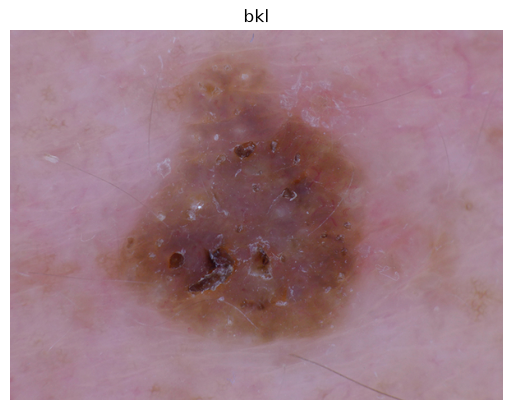

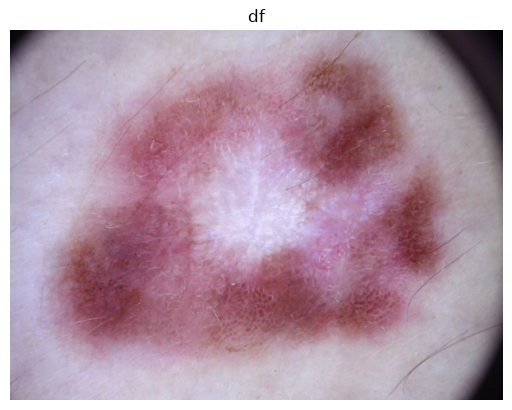

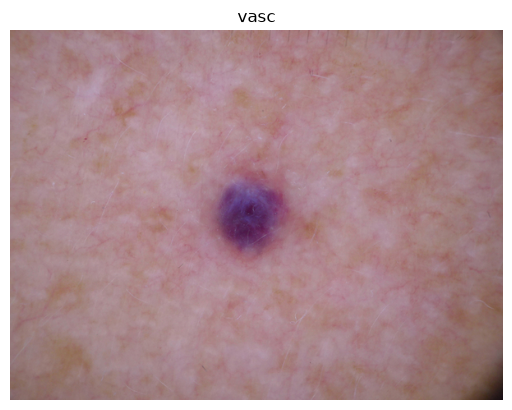

In [26]:
classes = train_data["dx"].unique()

for i in classes:

    sample = train_data[
        train_data["dx"] == i
    ].iloc[0]

    img = cv2.imread(sample["image_path"])

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(i)
    plt.axis("off")
    plt.show()